#### Testando os canais de uma imagem, como exemplo, e sua transformação para tom de cinza

In [37]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from math import ceil
import numpy as np

def plot_image_channels(img_path):
    img = cv2.imread(img_path)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para RGB (matplotlib trabalha com RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- 2. Separar canais ---
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 3. Exibir imagens lado a lado ---
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))

    axs[0].imshow(R, cmap='Reds')
    axs[0].set_title("Canal R")
    axs[0].axis("off")

    axs[1].imshow(G, cmap='Greens')
    axs[1].set_title("Canal G")
    axs[1].axis("off")

    axs[2].imshow(B, cmap='Blues')
    axs[2].set_title("Canal B")
    axs[2].axis("off")

    axs[3].imshow(gray, cmap='gray')
    axs[3].set_title("Cinza")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()
    
    return gray



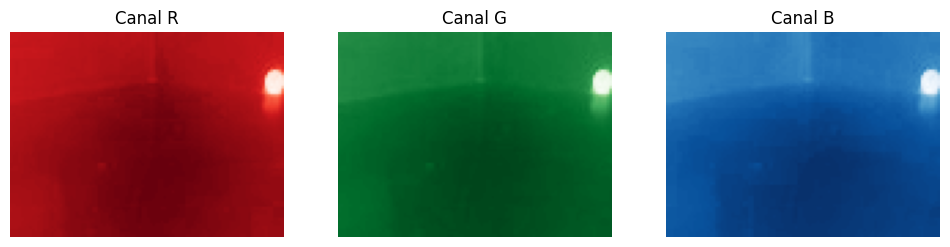

In [208]:
# separar imagem em RGB e mostrar
imMorta = cv2.imread('resized-images/ComVitimaMorta/20201029_100158.jpg')
imViva = cv2.imread('resized-images/ComVitimaViva/20201028_151211.jpg')
im = imMorta
b, g, r = cv2.split(im)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(r, cmap='Reds')
plt.title('Canal R')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(g, cmap='Greens')
plt.title('Canal G')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(b, cmap='Blues')
plt.title('Canal B')
plt.axis('off')
plt.show()


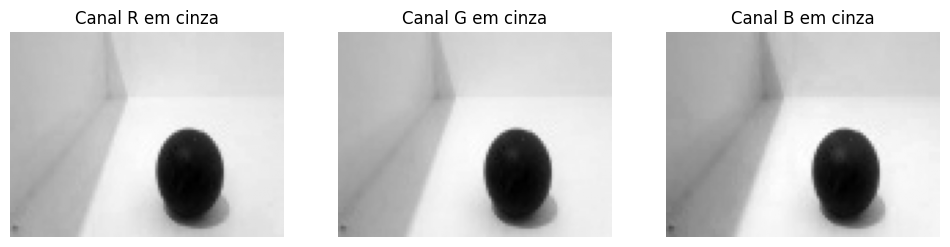

In [172]:
# CANAIS RGB EM TONS DE CINZA
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(r, cmap='gray')
plt.title('Canal R em cinza')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title('Canal G em cinza')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title('Canal B em cinza')

plt.axis('off')
plt.show()

In [177]:
im = imViva

In [191]:
# mostrar min e max de cada canal
b, g, r = cv2.split(im)
print(f'Canal R - min: {np.min(r)}, max: {np.max(r)}')
print(f'Canal G - min: {np.min(g)}, max: {np.max(g)}')
print(f'Canal B - min: {np.min(b)}, max: {np.max(b)}')

Canal R - min: 78, max: 181
Canal G - min: 79, max: 185
Canal B - min: 74, max: 198


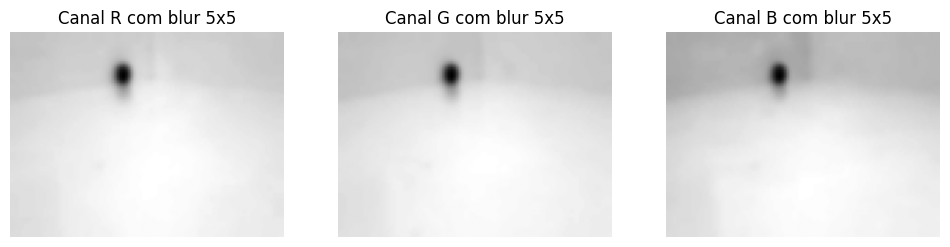

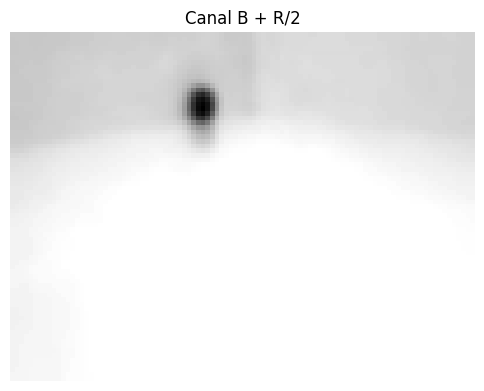

In [212]:
#media móvel 5x5 no canal nos canais RGB E SUBRTRAÇÃO DE B - R 
kernel_size = 5
r_blurred = cv2.GaussianBlur(r, (kernel_size, kernel_size), 0)
g_blurred = cv2.GaussianBlur(g, (kernel_size, kernel_size), 0)
b_blurred = cv2.GaussianBlur(b, (kernel_size, kernel_size), 0)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(r_blurred, cmap='gray')
plt.title('Canal R com blur 5x5')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(g_blurred, cmap='gray')
plt.title('Canal G com blur 5x5')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(b_blurred, cmap='gray')
plt.title('Canal B com blur 5x5')
plt.axis('off')
plt.show() 

# converter para float para operar
b_f = b_blurred.astype("float32")
r_f = r_blurred.astype("float32")

# divide
r_div = r_f / 1.5

# soma com OpenCV (agora que ambos são float32)
b_plus_r = cv2.add(b_f, r_div)

# volta para uint8 (faixa válida 0–255)
b_plus_r = np.clip(b_plus_r, 0, 255).astype("uint8")

# mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(b_plus_r, cmap='gray')
plt.title('Canal B + R/2')
plt.axis('off')
plt.show()

# quero executar todas imagens mostrar com esse scpyty e saçrver em nova pasta
import os
input_folder = 'resized-images/SemVitima'
output_folder = 'transformed-images/SemVitima_BplusRdiv1.5'
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        # ler imagem
        img_path = os.path.join(input_folder, filename)
        im = cv2.imread(img_path)
        
        # separar canais
        b, g, r = cv2.split(im)
        
        # aplicar blur
        kernel_size = 5
        r_blurred = cv2.GaussianBlur(r, (kernel_size, kernel_size), 0)
        b_blurred = cv2.GaussianBlur(b, (kernel_size, kernel_size), 0)
        
        # converter para float
        b_f = b_blurred.astype("float32")
        r_f = r_blurred.astype("float32")
        
        # dividir e somar
        r_div = r_f / 1.5
        b_plus_r = cv2.add(b_f, r_div)
        
        # voltar para uint8
        b_plus_r = np.clip(b_plus_r, 0, 255).astype("uint8")
        
        # salvar imagem transformada
        output_path = os.path.join(output_folder, filename)
        cv2.imwrite(output_path, b_plus_r)

# testar com vitimas mortas e sem vitimas 


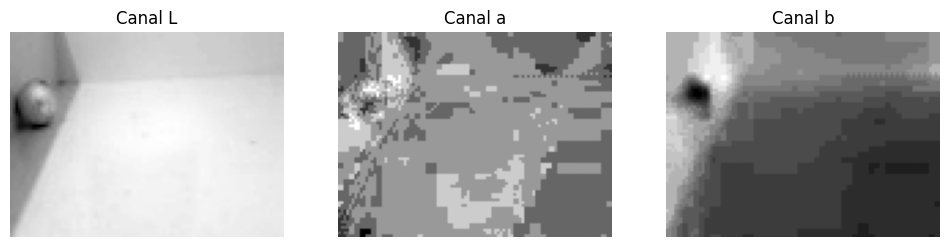

In [106]:
# canal Lab
lab = cv2.cvtColor(im, cv2.COLOR_BGR2Lab)
l, a, b = cv2.split(lab)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(l, cmap='gray')
plt.title('Canal L')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(a, cmap='gray')
plt.title('Canal a')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title('Canal b')
plt.axis('off')
plt.show()

In [ ]:
# aplicar media móvel 5x5 no canal b
kernel_size = 5
b_blurred = cv2.GaussianBlur(b, (kernel_size, kernel_size), 0)
plt.figure(figsize=(6,6))
plt.imshow(b_blurred, cmap='gray')
plt.title('Canal b com blur 5x5')
plt.axis('off')
plt.show()

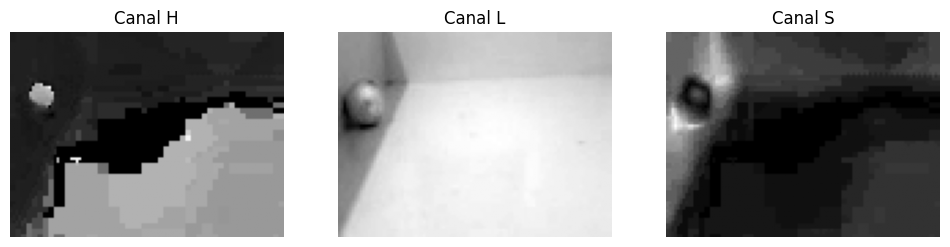

In [105]:
# canal hls
hls = cv2.cvtColor(im, cv2.COLOR_BGR2HLS)
h, l, s = cv2.split(hls)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(l, cmap='gray')
plt.title('Canal L')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(s, cmap='gray')
plt.title('Canal S')
plt.axis('off')
plt.show()



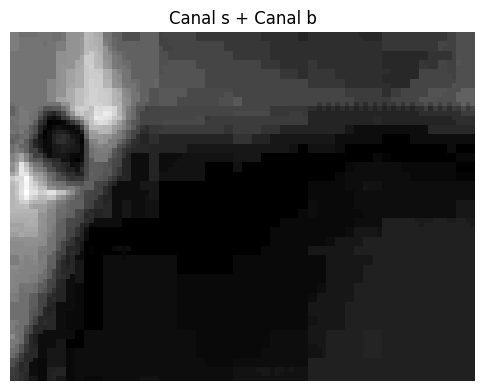

In [108]:
# soma do canal s + canal b
s_plus_b = cv2.add(s, b)
plt.figure(figsize=(6,6))
plt.imshow(s_plus_b, cmap='gray')
plt.title('Canal s + Canal b')
plt.axis('off')
plt.show()

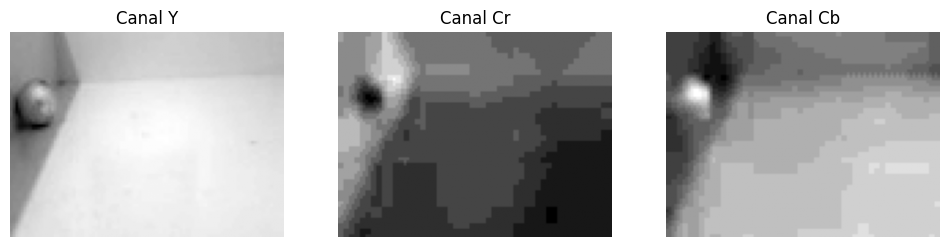

In [109]:
#canal YCrCb
ycrcb = cv2.cvtColor(im, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(cr, cmap='gray')
plt.title('Canal Cr')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(cb, cmap='gray')
plt.title('Canal Cb')
plt.axis('off')
plt.show()

In [124]:
import cv2
import os

# ====================== CONFIGURAÇÕES ======================
input_folder = "resized-images/ComVitimaMorta/"  # pasta de entrada
output_folder = "resultado/mortas"  # pasta de saída
# ===========================================================

# cria a pasta de saída caso não exista
os.makedirs(output_folder, exist_ok=True)

# extensões aceitas
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# percorre todas as imagens da pasta
for filename in os.listdir(input_folder):
    name, ext = os.path.splitext(filename)
    if ext.lower() not in valid_exts:
        continue
    
    img_path = os.path.join(input_folder, filename)
    print("Processando:", img_path)

    # 1. carregar imagem
    img = cv2.imread(img_path)

    if img is None:
        print("❌ Erro ao carregar:", img_path)
        continue

    # 2. converter para LUV
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # 4. salvar na pasta de saída
    out_path = os.path.join(output_folder, filename)
    cv2.imwrite(out_path, v_blurred)

print("\n✔ Finalizado! Imagens salvas em:", output_folder)


Processando: resized-images/ComVitimaMorta/20201029_100607.jpg
Processando: resized-images/ComVitimaMorta/20201126_120752.jpg
Processando: resized-images/ComVitimaMorta/20201126_115402.jpg
Processando: resized-images/ComVitimaMorta/20201126_123151.jpg
Processando: resized-images/ComVitimaMorta/20201126_122755.jpg
Processando: resized-images/ComVitimaMorta/20201029_100740.jpg
Processando: resized-images/ComVitimaMorta/20201126_122828.jpg
Processando: resized-images/ComVitimaMorta/20201126_112633.jpg
Processando: resized-images/ComVitimaMorta/20201126_122600.jpg
Processando: resized-images/ComVitimaMorta/20201126_122250.jpg
Processando: resized-images/ComVitimaMorta/20201029_095803.jpg
Processando: resized-images/ComVitimaMorta/20201029_100151.jpg
Processando: resized-images/ComVitimaMorta/20201126_115549.jpg
Processando: resized-images/ComVitimaMorta/20201126_114151.jpg
Processando: resized-images/ComVitimaMorta/20201126_113036.jpg
Processando: resized-images/ComVitimaMorta/20201029_101

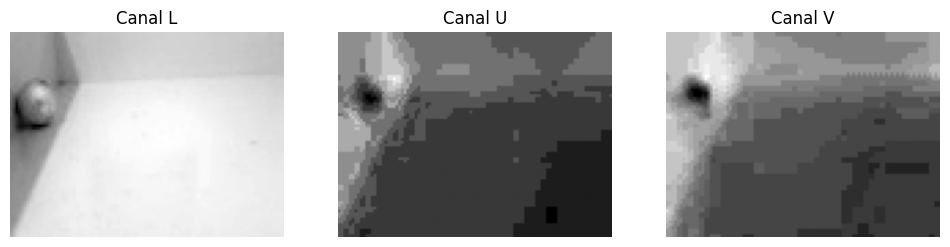

In [139]:
# canal LUV
luv = cv2.cvtColor(im, cv2.COLOR_BGR2Luv)
l, u, v = cv2.split(luv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(l, cmap='gray')
plt.title('Canal L')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(u, cmap='gray')
plt.title('Canal U')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()

In [166]:
imMorta = cv2.imread('resized-images/ComVitimaMorta/20201126_123050.jpg')
semVitima = cv2.imread('resized-images/SemVitima/20201126_153655.jpg')
im = semVitima
luv = cv2.cvtColor(im, cv2.COLOR_BGR2Luv)
l, u, v = cv2.split(luv)

In [164]:
print("dtype:", v.dtype, "min:", v.min(), "max:", v.max())

dtype: uint8 min: 131 max: 148


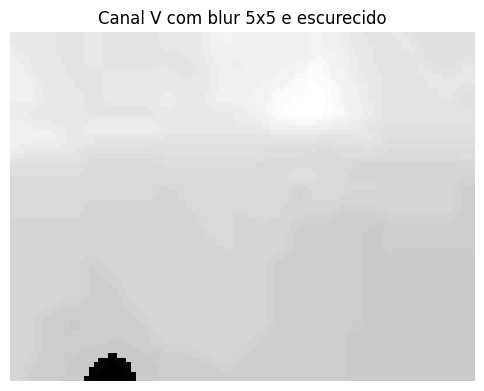

In [167]:
# aplicar media móvel 5x5 no canal V e quero escurecer o que for escuro
kernel_size = 5
v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)
v_blurred[v_blurred < 132] -= 50
plt.figure(figsize=(6,6))
plt.imshow(v_blurred, cmap='gray')
plt.title('Canal V com blur 5x5 e escurecido')
plt.axis('off')
plt.show()

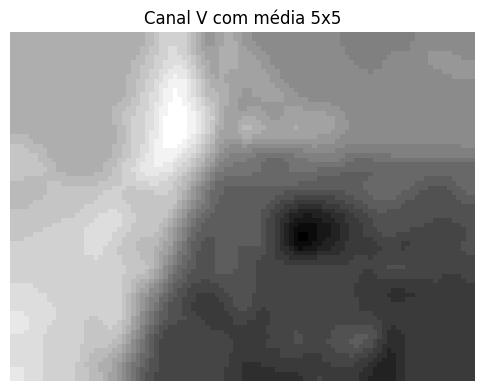

In [128]:
#aplicar media normal 5x5 no canal V
kernel = np.ones((5,5),np.float32)/25
v_mean = cv2.filter2D(v,-1,kernel)
plt.figure(figsize=(6,6))
plt.imshow(v_mean, cmap='gray')
plt.title('Canal V com média 5x5')
plt.axis('off')
plt.show()

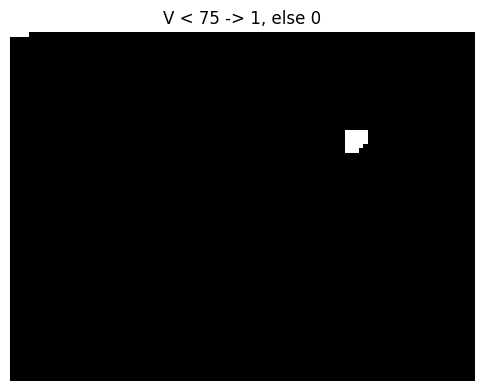

In [82]:
# binarizar: onde v for MUITO BAIXO (<75) -> 1, senão 0
v_bin01 = (v < 130).astype(np.uint8)

# mostrar (especificando vmin/vmax para matplotlib respeitar 0/1)
plt.figure(figsize=(6,6))
plt.imshow(v_bin01, cmap='gray', vmin=0, vmax=1)
plt.title('V < 75 -> 1, else 0')
plt.axis('off')
plt.show()

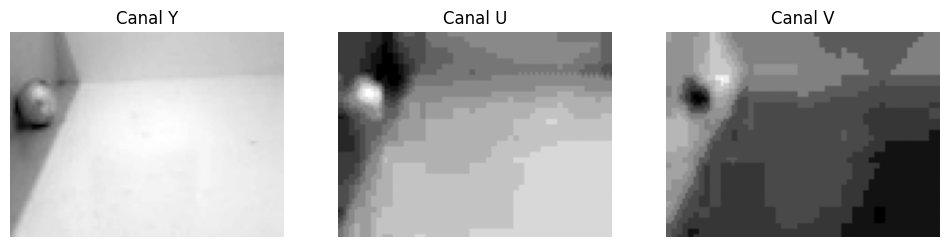

In [112]:
#canal YUV
yuv = cv2.cvtColor(im, cv2.COLOR_BGR2YUV)
y, u, v = cv2.split(yuv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(u, cmap='gray')
plt.title('Canal U')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()

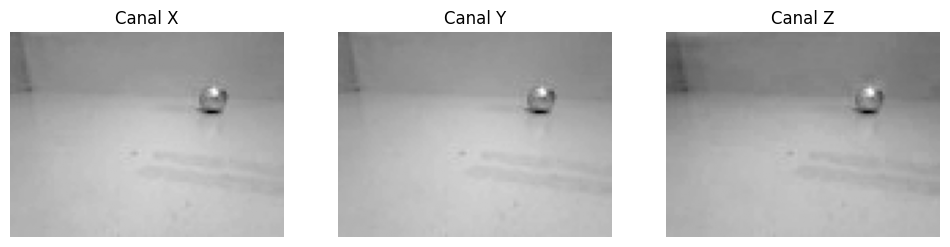

In [66]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

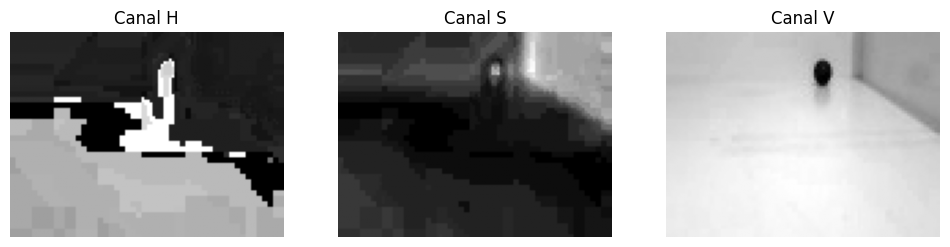

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


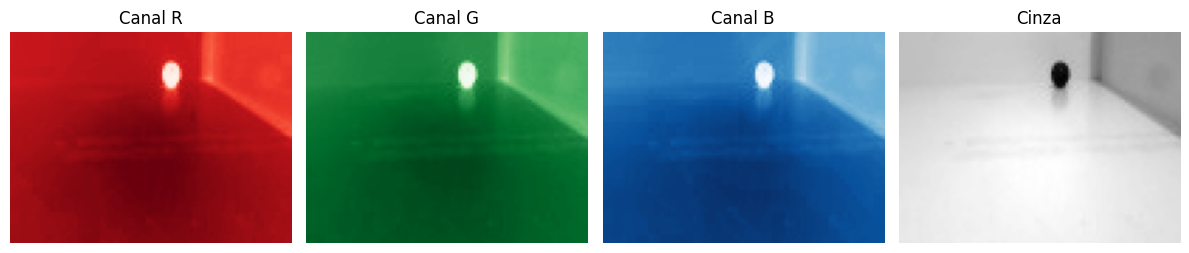

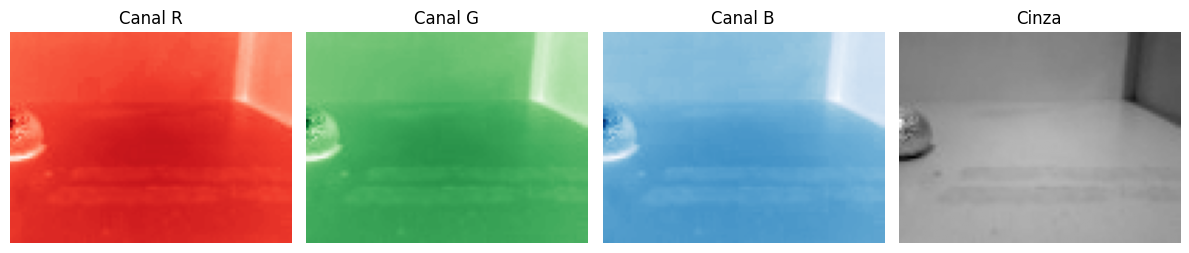

In [31]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [18]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

Total de imagens lidas: 0
Formato do DataFrame: (0, 0)


#### Adicionar RÓTULO 0 para Vítima MORTA

In [19]:
df_morta['y'] = 0

In [20]:
#df_morta.head()

In [21]:
#df_morta.shape

In [22]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

Total de imagens lidas: 0
Formato do DataFrame: (0, 0)


In [23]:
df_viva['y'] = 1

In [24]:
df_viva.shape

(0, 1)

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

Total de imagens lidas: 0
Formato do DataFrame: (0, 0)


In [26]:
df_sem['y'] = 2

In [27]:
#df_sem.shape

In [28]:
#df_sem.head()

#### Unido os três dataframes

In [29]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [ ]:
df_final.to_csv('imageset_gray_100_75.csv', index=False)


In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA

In [ ]:
df_morta['y'] = 0

In [ ]:
#df_morta.head()

In [ ]:
#df_morta.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

In [ ]:
df_viva['y'] = 1

In [ ]:
df_viva.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

In [ ]:
df_sem['y'] = 2

In [ ]:
#df_sem.shape

In [ ]:
#df_sem.head()

#### Unido os três dataframes

In [ ]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [ ]:
df_final.to_csv('imageset_gray_100_75.csv', index=False)

In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA

In [ ]:
df_morta['y'] = 0

In [ ]:
#df_morta.head()

In [ ]:
#df_morta.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

In [ ]:
df_viva['y'] = 1

In [ ]:
df_viva.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

In [ ]:
df_sem['y'] = 2

In [ ]:
#df_sem.shape

In [ ]:
#df_sem.head()

#### Unido os três dataframes

In [ ]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [ ]:
df_final.to_csv('imageset_gray_100_75.csv', index=False)

In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA

In [ ]:
df_morta['y'] = 0

In [ ]:
#df_morta.head()

In [ ]:
#df_morta.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

In [ ]:
df_viva['y'] = 1

In [ ]:
df_viva.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

In [ ]:
df_sem['y'] = 2

In [ ]:
#df_sem.shape

In [ ]:
#df_sem.head()

#### Unido os três dataframes

In [ ]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [ ]:
df_final.to_csv('imageset_gray_100_75.csv', index=False)

In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA

In [ ]:
df_morta['y'] = 0

In [ ]:
#df_morta.head()

In [ ]:
#df_morta.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

In [ ]:
df_viva['y'] = 1

In [ ]:
df_viva.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

In [ ]:
df_sem['y'] = 2

In [ ]:
#df_sem.shape

In [ ]:
#df_sem.head()

#### Unido os três dataframes

In [ ]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [ ]:
df_final.to_csv('imageset_gray_100_75.csv', index=False)

In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA

In [ ]:
df_morta['y'] = 0

In [ ]:
#df_morta.head()

In [ ]:
#df_morta.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_viva = "resized-images_100_75/ComVitimaViva/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_viva, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_viva = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_viva)}")
print(f"Formato do DataFrame: {df_viva.shape}")  # (n_imagens, 7500)

In [ ]:
df_viva['y'] = 1

In [ ]:
df_viva.shape

In [ ]:
# Caminho da pasta onde estão as imagens
folder_sem = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_sem, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (100, 75))    # garante 100x75

    #converte para luv
    luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)
    l, u, v = cv2.split(luv)

    # Aplicar blur 5x5 **somente no canal V**
    kernel_size = 5
    v_blurred = cv2.GaussianBlur(v, (kernel_size, kernel_size), 0)

    # --- 2. Flatten da imagem ---
    features = v_blurred.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 7500)

In [224]:
# -------------------------------------------------
def process_folder(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.jpg"))
    data_list = []

    for file in files:
        img = cv2.imread(file)

        if img is None:
            print("Erro ao carregar:", file)
            continue

        #tranformar para cinza 
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Flatten do canal
        features = gray.flatten()

        data_list.append(features)

    print(f"📌 Lidas {len(data_list)} imagens de: {folder_path}")
    return pd.DataFrame(data_list)


# =====================================================
# Pastas com as 3 classes
# =====================================================
folder_morta = "transformed-images/ComVitimaMorta_BplusRdiv1.5/"
folder_viva  = "transformed-images/ComVitimaViva_BplusRdiv1.5/"
folder_sem   = "transformed-images/SemVitima_BplusRdiv1.5/"


# =====================================================
# Gerar DataFrames
# =====================================================
df_morta = process_folder(folder_morta)
df_morta['y'] = 0
df_viva  = process_folder(folder_viva)
df_viva['y'] = 1
df_sem   = process_folder(folder_sem)
df_sem['y'] = 2

print("\nFormatos individuais:")
print("df_morta:", df_morta.shape)
print("df_viva :", df_viva.shape)
print("df_sem  :", df_sem.shape)

# =====================================================
# Concatenar tudo
# =====================================================
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

print("\nFormato final:", df_final.shape)

📌 Lidas 461 imagens de: transformed-images/ComVitimaMorta_BplusRdiv1.5/
📌 Lidas 461 imagens de: transformed-images/ComVitimaViva_BplusRdiv1.5/
📌 Lidas 461 imagens de: transformed-images/ComVitimaViva_BplusRdiv1.5/
📌 Lidas 462 imagens de: transformed-images/SemVitima_BplusRdiv1.5/
📌 Lidas 462 imagens de: transformed-images/SemVitima_BplusRdiv1.5/

Formatos individuais:
df_morta: (461, 7501)
df_viva : (461, 7501)
df_sem  : (462, 7501)

Formato final: (1384, 7501)

Formatos individuais:
df_morta: (461, 7501)
df_viva : (461, 7501)
df_sem  : (462, 7501)

Formato final: (1384, 7501)


In [ ]:
df_sem['y'] = 2

In [ ]:
#mostrar uma imagem do cvs salvo


In [ ]:
#df_sem.head()

#### Unido os três dataframes

In [ ]:
df_final = pd.concat([df_morta, df_viva, df_sem], ignore_index=True)

In [225]:
df_final.to_csv('imageset.csv', index=False)

In [ ]:
#canal XYZ
xyz = cv2.cvtColor(im, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x, cmap='gray')
plt.title('Canal X')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(z, cmap='gray')
plt.title('Canal Z')
plt.axis('off')
plt.show()

In [ ]:
#canal hsv
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title('Canal H') 
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title('Canal S')    
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title('Canal V')
plt.axis('off')
plt.show()


In [ ]:
# --- 1. Ler a imagem ---
vitima_morta_sample = 'resized-images/ComVitimaMorta/20201029_095407.jpg'
img_grey_1 = plot_image_channels(vitima_morta_sample)
vitima_viva_sample = 'resized-images/ComVitimaViva/20201028_151111.jpg'
img_grey_2 = plot_image_channels(vitima_viva_sample)

#### Vamos iterar em cada pasta e criar o dataframe com as features

In [ ]:

import glob
import os
# Caminho da pasta onde estão as imagens
folder_morta = "resized-images_100_75/ComVitimaMorta/"   # ajuste para o seu diretório

# Lista de arquivos .jpg
files = glob.glob(os.path.join(folder_morta, "*.jpg"))

# Lista para armazenar os vetores de cada imagem
data_list = []

for file in files:
    # --- 1. Ler a imagem ---
    img = cv2.imread(file)  # lê em BGR
    #img = cv2.resize(img, (640, 480))    # garante resolução compatível com treinamento

    # Converter para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 2. Flatten da imagem ---
    features = gray.flatten()

    # Adiciona ao dataset
    data_list.append(features)

# --- 3. Criar DataFrame ---
df_morta = pd.DataFrame(data_list)

print(f"Total de imagens lidas: {len(df_morta)}")
print(f"Formato do DataFrame: {df_morta.shape}")  # (n_imagens, 640x480)

#### Adicionar RÓTULO 0 para Vítima MORTA